# Лабораторная работа №4.2

**Студент:** Тавуз Мохамад  
**Группа:** ИУ5И-22М  
**Вариант:** 2

**Тема:** Необходимые и достаточные условия существования условного
экстремума


In [1]:
# Импорт необходимых библиотек для выполнения лабораторной работы

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
import time

from scipy.optimize import minimize

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Задание варианта, целевой функции и ограничений задачи

variant = 2

def objective_function(x):
    x1, x2 = x
    return x1**2 + (x2 - x1)**3

def constraints(x):
    x1, x2 = x
    g1 = x1**2 + x2**2 - 1
    g2 = x1 - x2
    return np.array([g1, g2], dtype=float)

def constraint_violation(x):
    g = constraints(x)
    return np.sum(np.maximum(g, 0.0) ** 2)

def is_feasible(x, tolerance=1e-8):
    return np.all(constraints(x) <= tolerance)

print("Variant:", variant)
print("Objective function: f(x) = x1^2 + (x2 - x1)^3")
print("Constraints:")
print("g1(x) = x1^2 + x2^2 - 1 <= 0")
print("g2(x) = x1 - x2 <= 0")

Variant: 2
Objective function: f(x) = x1^2 + (x2 - x1)^3
Constraints:
g1(x) = x1^2 + x2^2 - 1 <= 0
g2(x) = x1 - x2 <= 0


In [3]:
# Проверка целевой функции, ограничений и допустимости тестовых точек

test_points = [
    np.array([0.0, 0.0]),
    np.array([0.5, 0.5]),
    np.array([1.0, 1.0]),
    np.array([-0.5, 0.5]),
    np.array([0.7, 0.8])
]

for point in test_points:
    print("Point:", point)
    print("f(x):", objective_function(point))
    print("g(x):", constraints(point))
    print("Constraint violation:", constraint_violation(point))
    print("Feasible:", is_feasible(point))
    print("-" * 50)

Point: [0. 0.]
f(x): 0.0
g(x): [-1.  0.]
Constraint violation: 0.0
Feasible: True
--------------------------------------------------
Point: [0.5 0.5]
f(x): 0.25
g(x): [-0.5  0. ]
Constraint violation: 0.0
Feasible: True
--------------------------------------------------
Point: [1. 1.]
f(x): 1.0
g(x): [1. 0.]
Constraint violation: 1.0
Feasible: False
--------------------------------------------------
Point: [-0.5  0.5]
f(x): 1.25
g(x): [-0.5 -1. ]
Constraint violation: 0.0
Feasible: True
--------------------------------------------------
Point: [0.7 0.8]
f(x): 0.49099999999999994
g(x): [ 0.13 -0.1 ]
Constraint violation: 0.01690000000000003
Feasible: False
--------------------------------------------------


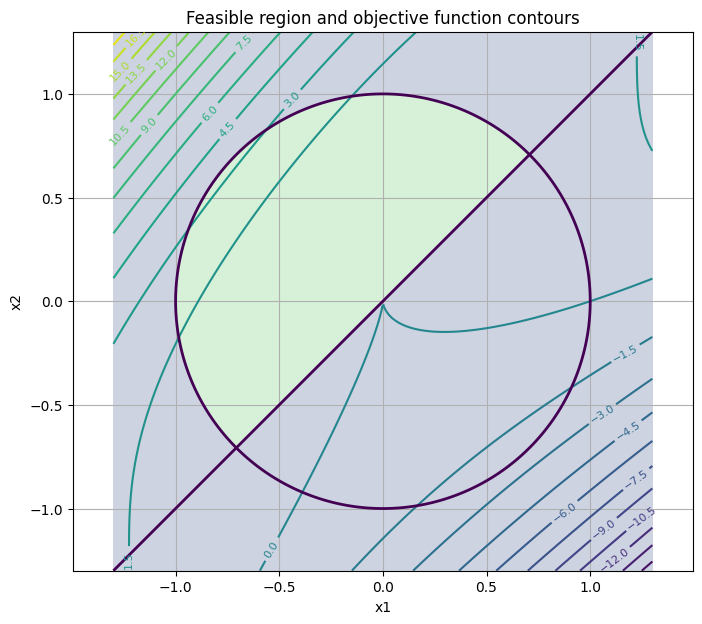

In [4]:
# Визуализация области допустимых решений и линий уровня целевой функции

x1_values = np.linspace(-1.3, 1.3, 400)
x2_values = np.linspace(-1.3, 1.3, 400)
X1, X2 = np.meshgrid(x1_values, x2_values)

F = X1**2 + (X2 - X1)**3
G1 = X1**2 + X2**2 - 1
G2 = X1 - X2

feasible_region = (G1 <= 0) & (G2 <= 0)

plt.figure(figsize=(8, 7))

plt.contourf(X1, X2, feasible_region, levels=[-0.5, 0.5, 1.5], alpha=0.25)
contours = plt.contour(X1, X2, F, levels=25)
plt.clabel(contours, inline=True, fontsize=8)

plt.contour(X1, X2, G1, levels=[0], linewidths=2)
plt.contour(X1, X2, G2, levels=[0], linewidths=2)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Feasible region and objective function contours")
plt.grid(True)
plt.axis("equal")
plt.show()

In [5]:
# Символьное решение условий Куна-Таккера для разных активных ограничений

x1, x2, mu1, mu2 = sp.symbols("x1 x2 mu1 mu2", real=True)

f_sym = x1**2 + (x2 - x1)**3
g1_sym = x1**2 + x2**2 - 1
g2_sym = x1 - x2

L_sym = f_sym + mu1 * g1_sym + mu2 * g2_sym

stationarity_equations = [
    sp.diff(L_sym, x1),
    sp.diff(L_sym, x2)
]

cases = {
    "No active constraints": [
        stationarity_equations[0],
        stationarity_equations[1],
        mu1,
        mu2
    ],
    "Only g1 active": [
        stationarity_equations[0],
        stationarity_equations[1],
        g1_sym,
        mu2
    ],
    "Only g2 active": [
        stationarity_equations[0],
        stationarity_equations[1],
        mu1,
        g2_sym
    ],
    "g1 and g2 active": [
        stationarity_equations[0],
        stationarity_equations[1],
        g1_sym,
        g2_sym
    ]
}

solutions = []

for case_name, equations in cases.items():
    print("=" * 70)
    print("Case:", case_name)

    case_solutions = sp.solve(equations, [x1, x2, mu1, mu2], dict=True)

    for sol in case_solutions:
        x1_complex = complex(sp.N(sol[x1]))
        x2_complex = complex(sp.N(sol[x2]))
        mu1_complex = complex(sp.N(sol.get(mu1, 0)))
        mu2_complex = complex(sp.N(sol.get(mu2, 0)))

        if (
            abs(x1_complex.imag) > 1e-8 or
            abs(x2_complex.imag) > 1e-8 or
            abs(mu1_complex.imag) > 1e-8 or
            abs(mu2_complex.imag) > 1e-8
        ):
            continue

        x_candidate = np.array([
            x1_complex.real,
            x2_complex.real
        ])

        mu1_value = mu1_complex.real
        mu2_value = mu2_complex.real

        g_values = constraints(x_candidate)
        f_value = objective_function(x_candidate)
        feasible = is_feasible(x_candidate)
        kkt_dual_feasible = (mu1_value >= -1e-8) and (mu2_value >= -1e-8)

        result = {
            "case": case_name,
            "x1": x_candidate[0],
            "x2": x_candidate[1],
            "mu1": mu1_value,
            "mu2": mu2_value,
            "f": f_value,
            "g1": g_values[0],
            "g2": g_values[1],
            "feasible": feasible,
            "dual_feasible": kkt_dual_feasible
        }

        solutions.append(result)
        print(result)

solutions_df = pd.DataFrame(solutions)
solutions_df

Case: No active constraints
{'case': 'No active constraints', 'x1': np.float64(0.0), 'x2': np.float64(0.0), 'mu1': 0.0, 'mu2': 0.0, 'f': np.float64(0.0), 'g1': np.float64(-1.0), 'g2': np.float64(0.0), 'feasible': np.True_, 'dual_feasible': True}
Case: Only g1 active
{'case': 'Only g1 active', 'x1': np.float64(-0.7845056516151699), 'x2': np.float64(0.6201216675652106), 'mu1': -4.7723971173295325, 'mu2': 0.0, 'f': np.float64(3.3867477840250686), 'g1': np.float64(0.0), 'g2': np.float64(-1.4046273191803804), 'feasible': np.True_, 'dual_feasible': False}
{'case': 'Only g1 active', 'x1': np.float64(0.6201216675652106), 'x2': np.float64(-0.7845056516151699), 'mu1': 3.772397117329533, 'mu2': 0.0, 'f': np.float64(-2.3867477840250686), 'g1': np.float64(0.0), 'g2': np.float64(1.4046273191803804), 'feasible': np.False_, 'dual_feasible': True}
{'case': 'Only g1 active', 'x1': np.float64(0.8940396099217013), 'x2': np.float64(0.44798791935838206), 'mu1': -0.6661857453857891, 'mu2': 0.0, 'f': np.float

,case,x1,x2,mu1,mu2,f,g1,g2,feasible,dual_feasible
0,No active constraints,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000e+00,0.000000,True,True
1,Only g1 active,-0.784506,0.620122,-4.772397,0.000000,3.386748,0.000000e+00,-1.404627,True,False
2,Only g1 active,0.620122,-0.784506,3.772397,0.000000,-2.386748,0.000000e+00,1.404627,False,True
3,Only g1 active,0.894040,0.447988,-0.666186,0.000000,0.710559,0.000000e+00,0.446052,False,False
4,Only g1 active,0.447988,0.894040,-0.333814,0.000000,0.289441,0.000000e+00,-0.446052,True,False
5,Only g2 active,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000e+00,0.000000,True,True
6,g1 and g2 active,0.707107,0.707107,-0.500000,-0.707107,0.500000,2.220446e-16,0.000000,True,False
7,g1 and g2 active,-0.707107,-0.707107,-0.500000,0.707107,0.500000,2.220446e-16,0.000000,True,False


In [6]:
# Фильтрация допустимых точек, удовлетворяющих условиям Куна-Таккера

valid_kkt_points = solutions_df[
    (solutions_df["feasible"] == True) &
    (solutions_df["dual_feasible"] == True)
].copy()

valid_kkt_points = valid_kkt_points.drop_duplicates(
    subset=["x1", "x2", "f"],
    keep="first"
).reset_index(drop=True)

print("Valid KKT points:")
display(valid_kkt_points)

best_point_index = valid_kkt_points["f"].idxmin()
best_point = valid_kkt_points.loc[best_point_index]

print("Best point among valid KKT candidates:")
print("x* =", np.array([best_point["x1"], best_point["x2"]]))
print("f(x*) =", best_point["f"])
print("g(x*) =", np.array([best_point["g1"], best_point["g2"]]))

Valid KKT points:


,case,x1,x2,mu1,mu2,f,g1,g2,feasible,dual_feasible
0,No active constraints,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,True,True


Best point among valid KKT candidates:
x* = [0. 0.]
f(x*) = 0.0
g(x*) = [-1.  0.]


In [7]:
# Определение условного максимума среди точек Куна-Таккера

valid_kkt_max_points = solutions_df[
    (solutions_df["feasible"] == True) &
    (solutions_df["mu1"] <= 1e-8) &
    (solutions_df["mu2"] <= 1e-8)
].copy()

valid_kkt_max_points = valid_kkt_max_points.drop_duplicates(
    subset=["x1", "x2", "f"],
    keep="first"
).reset_index(drop=True)

print("Valid KKT points for maximum:")
display(valid_kkt_max_points)

max_point_index = valid_kkt_max_points["f"].idxmax()
max_point = valid_kkt_max_points.loc[max_point_index]

x_max = np.array([max_point["x1"], max_point["x2"]])

print("Best point for maximum among valid KKT candidates:")
print("x_max =", x_max)
print("f(x_max) =", max_point["f"])
print("g(x_max) =", np.array([max_point["g1"], max_point["g2"]]))
print("mu_max =", np.array([max_point["mu1"], max_point["mu2"]]))

Valid KKT points for maximum:


,case,x1,x2,mu1,mu2,f,g1,g2,feasible,dual_feasible
0,No active constraints,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000e+00,0.000000,True,True
1,Only g1 active,-0.784506,0.620122,-4.772397,0.000000,3.386748,0.000000e+00,-1.404627,True,False
2,Only g1 active,0.447988,0.894040,-0.333814,0.000000,0.289441,0.000000e+00,-0.446052,True,False
3,g1 and g2 active,0.707107,0.707107,-0.500000,-0.707107,0.500000,2.220446e-16,0.000000,True,False


Best point for maximum among valid KKT candidates:
x_max = [-0.78450565  0.62012167]
f(x_max) = 3.3867477840250686
g(x_max) = [ 0.         -1.40462732]
mu_max = [-4.77239712  0.        ]


In [8]:
# Проверка условий второго порядка в найденной точке

hessian_L = sp.hessian(L_sym, (x1, x2))

x_star = np.array([best_point["x1"], best_point["x2"]])
mu_star = np.array([best_point["mu1"], best_point["mu2"]])

hessian_at_star = hessian_L.subs({
    x1: x_star[0],
    x2: x_star[1],
    mu1: mu_star[0],
    mu2: mu_star[1]
})

hessian_at_star_np = np.array(hessian_at_star, dtype=float)
eigenvalues = np.linalg.eigvals(hessian_at_star_np)

print("x* =", x_star)
print("mu* =", mu_star)
print("Hessian of Lagrangian at x*:")
print(hessian_at_star_np)
print("Eigenvalues:", eigenvalues)

print("\nSecond-order condition analysis:")
if np.all(eigenvalues >= -1e-8):
    print("The Hessian is positive semidefinite.")
    print("The second-order necessary condition for a local minimum is satisfied.")
else:
    print("The Hessian is not positive semidefinite.")
    print("The second-order necessary condition is not satisfied.")

x* = [0. 0.]
mu* = [0. 0.]
Hessian of Lagrangian at x*:
[[2. 0.]
 [0. 0.]]
Eigenvalues: [2. 0.]

Second-order condition analysis:
The Hessian is positive semidefinite.
The second-order necessary condition for a local minimum is satisfied.


In [9]:
# Численное решение задачи условной оптимизации методом SLSQP

x0 = np.array([0.2, 0.2])

scipy_constraints = [
    {
        "type": "ineq",
        "fun": lambda x: 1 - x[0]**2 - x[1]**2
    },
    {
        "type": "ineq",
        "fun": lambda x: x[1] - x[0]
    }
]

start_time = time.time()

numerical_result = minimize(
    objective_function,
    x0,
    method="SLSQP",
    constraints=scipy_constraints,
    options={
        "ftol": 1e-12,
        "maxiter": 1000,
        "disp": False
    }
)

execution_time = time.time() - start_time

x_numerical = numerical_result.x
f_numerical = objective_function(x_numerical)
g_numerical = constraints(x_numerical)

print("Numerical optimization result:")
print("Success:", numerical_result.success)
print("Message:", numerical_result.message)
print("Found point:", x_numerical)
print("Function value:", f_numerical)
print("Constraints:", g_numerical)
print("Constraint violation:", constraint_violation(x_numerical))
print("Feasible:", is_feasible(x_numerical))
print("Iterations:", numerical_result.nit)
print("Execution time:", execution_time)

Numerical optimization result:
Success: True
Message: Optimization terminated successfully
Found point: [-7.4538278e-09  7.2792057e-05]
Function value: 3.858761336636238e-13
Constraints: [-9.99999995e-01 -7.27995108e-05]
Constraint violation: 0.0
Feasible: True
Iterations: 18
Execution time: 0.030282020568847656


In [10]:
# Сравнение аналитического и численного решений задачи

comparison_data = [
    {
        "Method": "KKT symbolic solution",
        "x1": x_star[0],
        "x2": x_star[1],
        "f(x)": objective_function(x_star),
        "g1(x)": constraints(x_star)[0],
        "g2(x)": constraints(x_star)[1],
        "Feasible": is_feasible(x_star)
    },
    {
        "Method": "SLSQP numerical solution",
        "x1": x_numerical[0],
        "x2": x_numerical[1],
        "f(x)": f_numerical,
        "g1(x)": g_numerical[0],
        "g2(x)": g_numerical[1],
        "Feasible": is_feasible(x_numerical)
    }
]

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Method,x1,x2,f(x),g1(x),g2(x),Feasible
0,KKT symbolic solution,0.000000e+00,0.000000,0.000000e+00,-1.0,0.000000,True
1,SLSQP numerical solution,-7.453828e-09,0.000073,3.858761e-13,-1.0,-0.000073,True


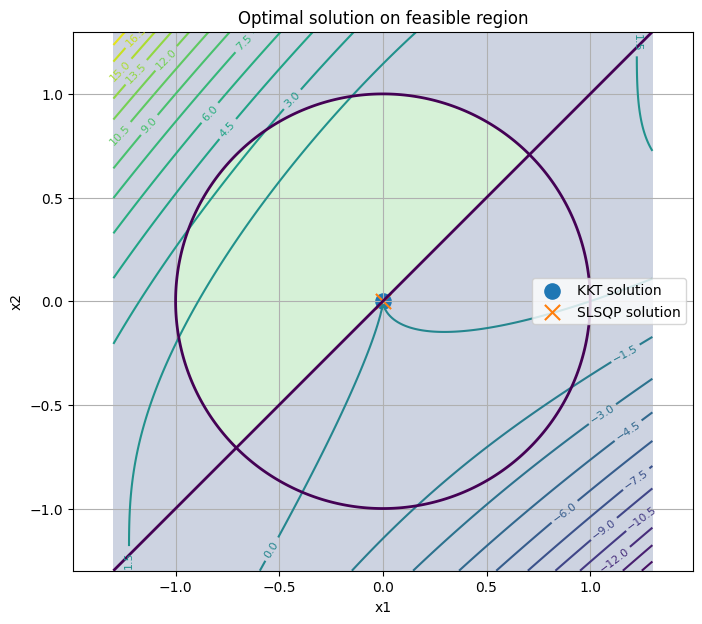

In [11]:
# Визуализация найденного решения на области допустимых решений

plt.figure(figsize=(8, 7))

plt.contourf(X1, X2, feasible_region, levels=[-0.5, 0.5, 1.5], alpha=0.25)
contours = plt.contour(X1, X2, F, levels=25)
plt.clabel(contours, inline=True, fontsize=8)

plt.contour(X1, X2, G1, levels=[0], linewidths=2)
plt.contour(X1, X2, G2, levels=[0], linewidths=2)

plt.scatter(x_star[0], x_star[1], s=120, marker="o", label="KKT solution")
plt.scatter(x_numerical[0], x_numerical[1], s=120, marker="x", label="SLSQP solution")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Optimal solution on feasible region")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

In [12]:
# Итоговая проверка найденного решения

def objective_gradient(x):
    x1, x2 = x
    df_dx1 = 2 * x1 - 3 * (x2 - x1)**2
    df_dx2 = 3 * (x2 - x1)**2
    return np.array([df_dx1, df_dx2], dtype=float)

gradient_at_star = objective_gradient(x_star)
gradient_norm_at_star = np.linalg.norm(gradient_at_star)

final_check_data = {
    "x*": x_star,
    "f(x*)": objective_function(x_star),
    "g(x*)": constraints(x_star),
    "constraint_violation": constraint_violation(x_star),
    "feasible": is_feasible(x_star),
    "gradient": gradient_at_star,
    "gradient_norm": gradient_norm_at_star
}

for key, value in final_check_data.items():
    print(key, ":", value)

x* : [0. 0.]
f(x*) : 0.0
g(x*) : [-1.  0.]
constraint_violation : 0.0
feasible : True
gradient : [0. 0.]
gradient_norm : 0.0


In [13]:
# Формирование итоговой таблицы результатов

final_results = pd.DataFrame([
    {
        "Variant": variant,
        "x1*": x_star[0],
        "x2*": x_star[1],
        "f(x*)": objective_function(x_star),
        "g1(x*)": constraints(x_star)[0],
        "g2(x*)": constraints(x_star)[1],
        "Constraint violation": constraint_violation(x_star),
        "Gradient norm": gradient_norm_at_star,
        "Feasible": is_feasible(x_star)
    }
])

final_results

,Variant,x1*,x2*,f(x*),g1(x*),g2(x*),Constraint violation,Gradient norm,Feasible
0,2,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,True
